# Day 11 — Physical (Per Capita)
### #30DayChartChallenge | April 2026

**E-Waste Per Person: Who Throws Away the Most?** Same circle-packing approach as the total chart, but now each bubble scales to kg of e-waste per person. The story flips — Norway (26.8 kg) and UK (24.5 kg) dominate, while China (8.5 kg) and India (2.9 kg) rank far lower.

**Data:** Global E-waste Monitor 2024 (UNITAR/ITU) via [globalewaste.org](https://globalewaste.org/map/)  
**Author:** Sharfudeen Yasar Arafath

In [1]:
# — packages ------------------------------------------------------------------

library(ggplot2)
library(dplyr)
library(packcircles)
library(showtext)
library(sysfonts)
library(ggimage)
library(countrycode)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'packcircles' was built under R version 4.5.3"
Loading required package: sysfonts

Loading required package: showtextdb

Warning message:
"package 'ggimage' was built under R version 4.5.3"
Warning message:
"package 'countrycode' was built under R version 4.5.3"


In [2]:
# — fonts & display size ------------------------------------------------------

font_add_google("Outfit", "outfit")
font_add_google("Roboto Condensed", "roboto_condensed")
font_add_google("JetBrains Mono", "jetbrains")
showtext_auto()
showtext_opts(dpi = 300)

options(repr.plot.width = 12, repr.plot.height = 10, repr.plot.res = 300)

In [3]:
# — read & process data -------------------------------------------------------

df <- read.csv("../../data/day_11/ewaste_percapita.csv", stringsAsFactors = FALSE)

# Circle packing layout (area proportional to per capita kg)
packing <- circleProgressiveLayout(df$percapita_kg, sizetype = "area")
df <- cbind(df, packing)

dat.gg <- circleLayoutVertices(packing, npoints = 100)
dat.gg$region <- df$region[dat.gg$id]

# Flags
df$iso2 <- tolower(countrycode(df$country, "country.name", "iso2c",
  custom_match = c("Taiwan" = "tw", "Hong Kong" = "hk")))
df$flag_url <- paste0("https://flagcdn.com/w160/", df$iso2, ".png")
plot_width <- max(dat.gg$x) - min(dat.gg$x)
df$flag_size <- (df$radius * 1.05) / plot_width

# Three tiers for labeling
big   <- df %>% filter(radius > 0.8)
mid   <- df %>% filter(radius > 0.5 & radius <= 0.8)
small <- df %>% filter(radius > 0.35 & radius <= 0.5)

head(df)

,country,region,percapita_kg,total_mt,iso3,x,y,radius,iso2,flag_url,flag_size
,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
1,Norway,Europe,26.8,0.14,NOR,-2.92073706,0.0000000,2.920737,no,https://flagcdn.com/w160/no.png,0.07085426
2,United Kingdom,Europe,24.5,1.65,GBR,2.79259596,0.0000000,2.792596,gb,https://flagcdn.com/w160/gb.png,0.06774568
3,Switzerland,Europe,23.4,0.20,CHE,0.06121134,-4.7989170,2.729185,ch,https://flagcdn.com/w160/ch.png,0.06620739
4,Australia,Oceania,22.4,0.58,AUS,0.05988912,4.7302017,2.670232,au,https://flagcdn.com/w160/au.png,0.06477726
5,France,Europe,22.4,1.45,FRA,5.39989177,4.8004690,2.670232,fr,https://flagcdn.com/w160/fr.png,0.06477726
6,Iceland,Europe,22.4,0.01,ISL,8.24809362,0.2829131,2.670232,is,https://flagcdn.com/w160/is.png,0.06477726


In [4]:
# — theme & palette -----------------------------------------------------------

bg       <- "#0a0e17"
txt      <- "#E6EDF3"
txt_dim  <- "#8B949E"
txt_cap  <- "#484F58"

region_colors <- c(
  "Asia"     = "#F43F5E",
  "Americas" = "#3B82F6",
  "Europe"   = "#10B981",
  "Africa"   = "#F59E0B",
  "Oceania"  = "#8B5CF6"
)

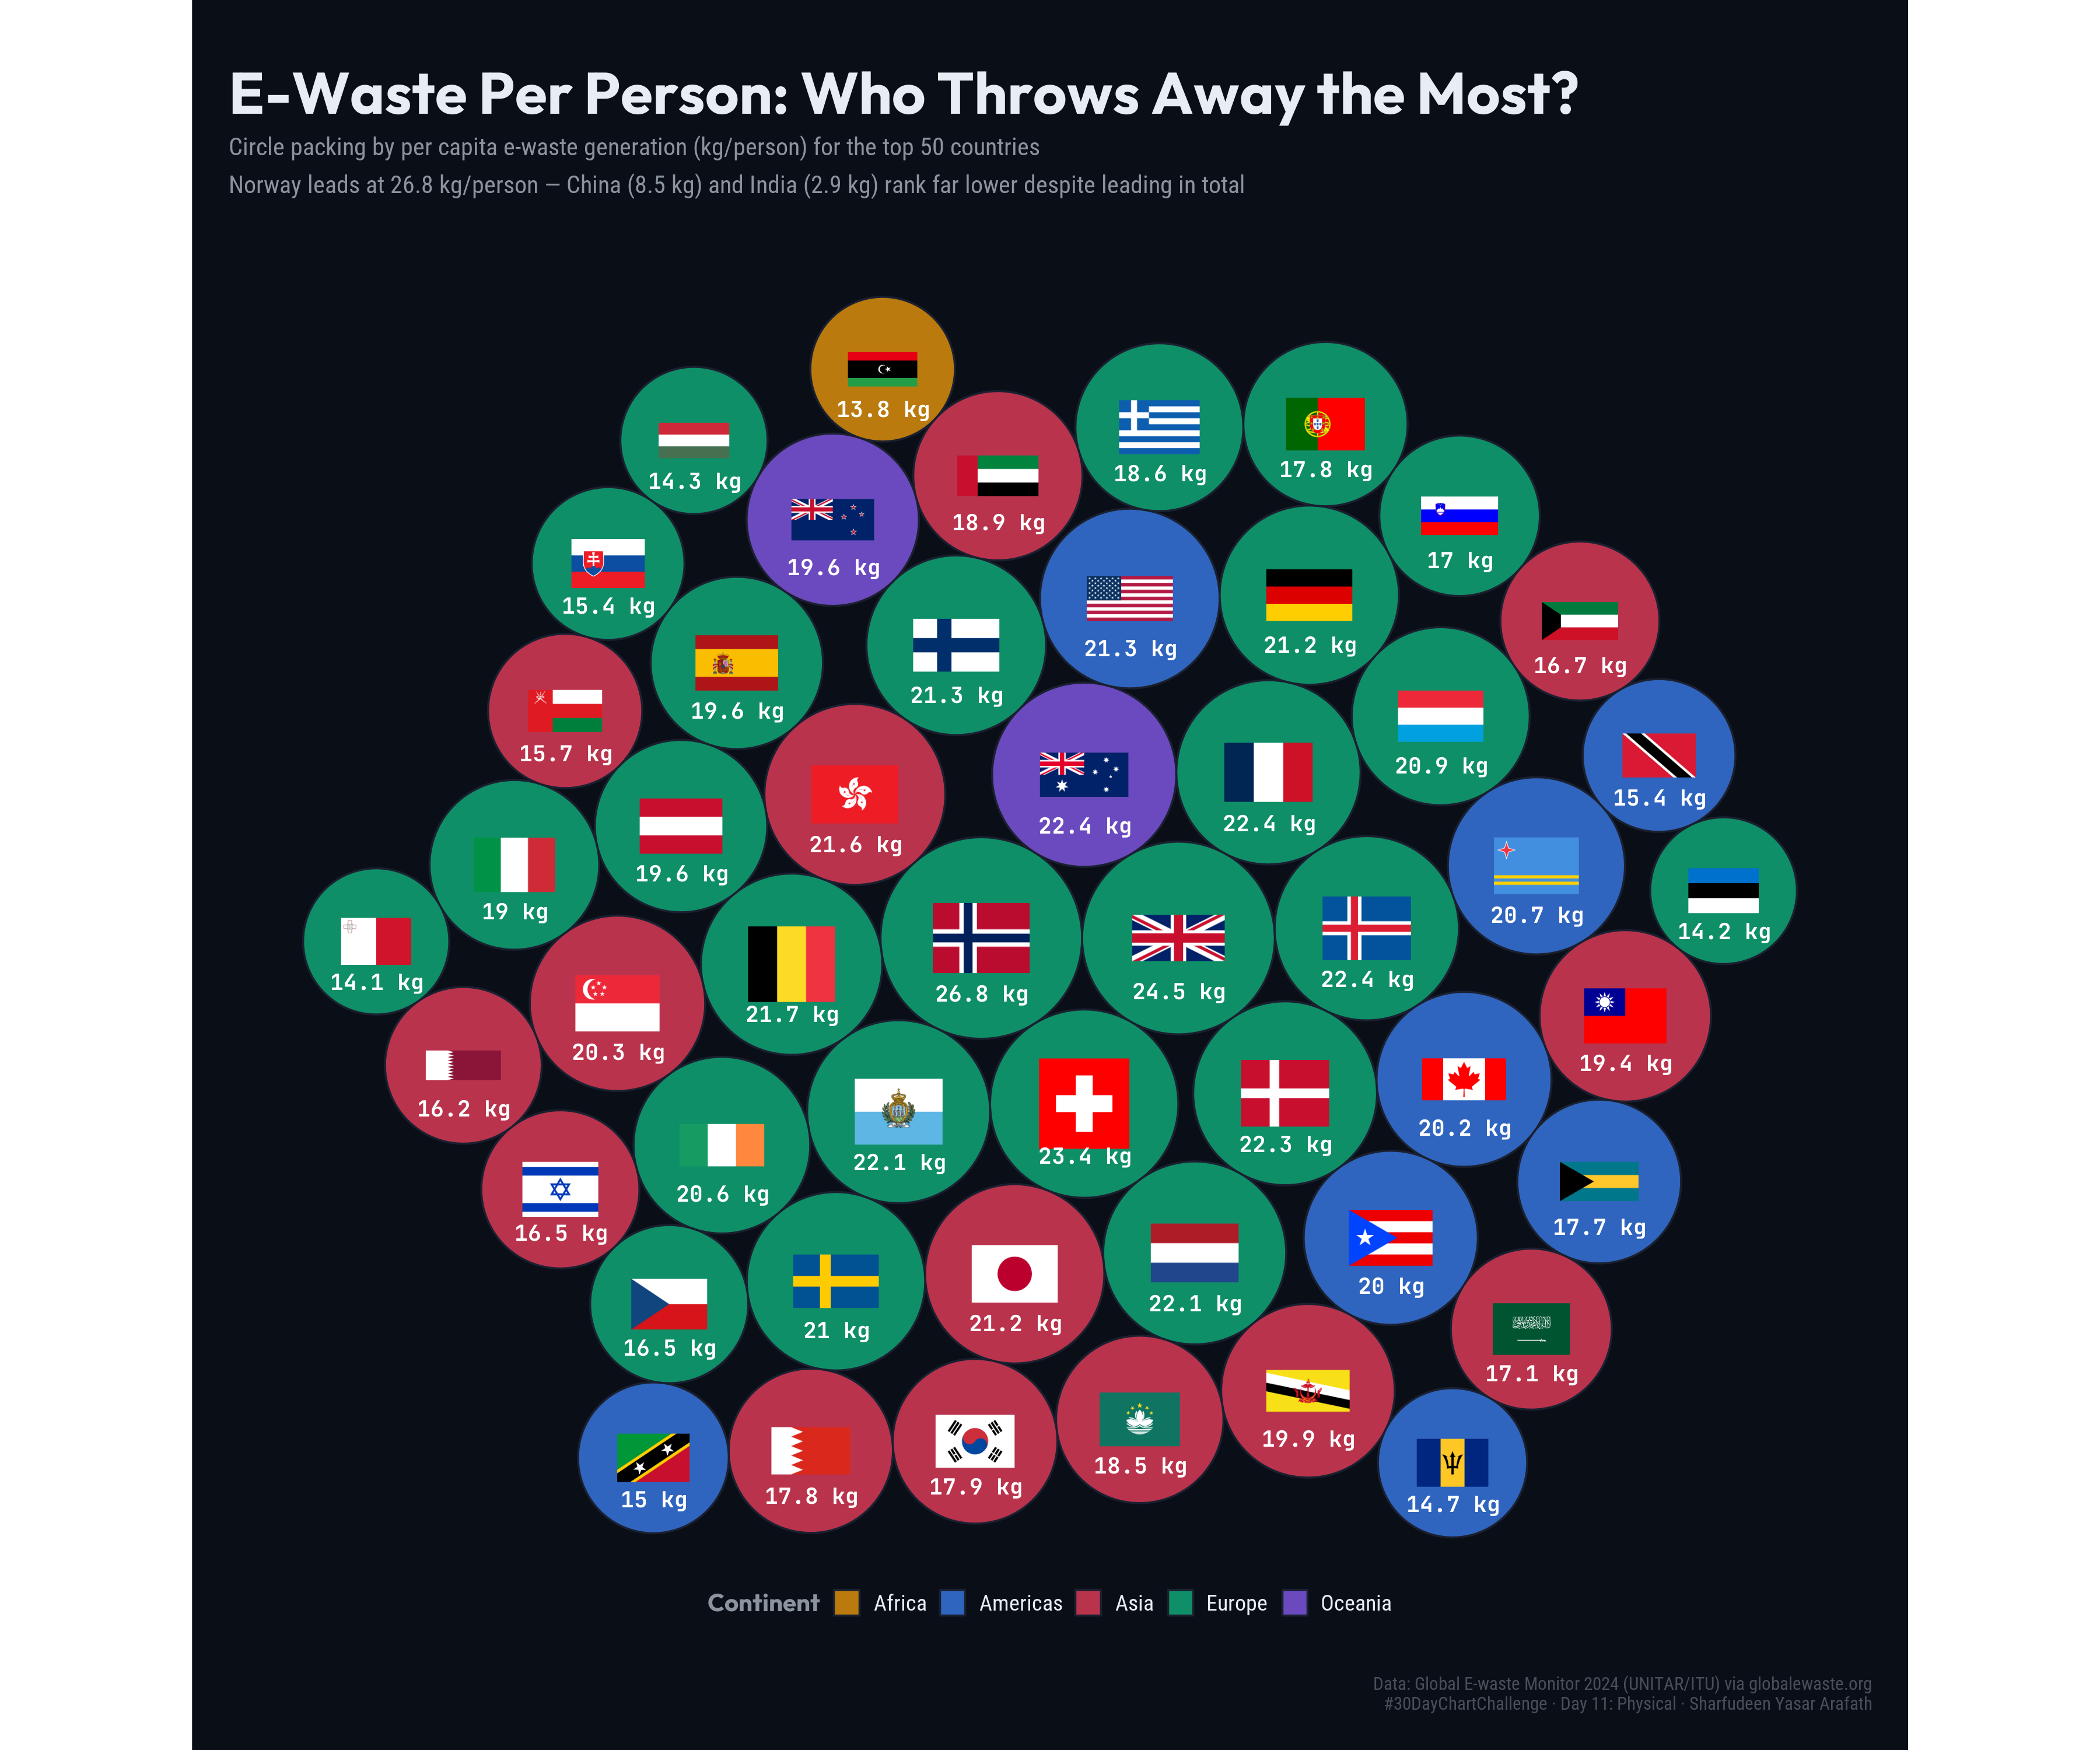

In [5]:
# — build the plot ------------------------------------------------------------

p <- ggplot() +

  geom_polygon(data = dat.gg,
    aes(x = x, y = y, group = id, fill = region),
    color = "#1a2030", alpha = 0.75, linewidth = 0.3) +

  geom_image(data = df,
    aes(x, y, image = flag_url, size = I(flag_size))) +

  geom_text(data = big,
    aes(x, y - radius * 0.55, label = paste0(percapita_kg, " kg")),
    family = "jetbrains", fontface = "bold",
    size = 3.2, color = "#FFFFFF") +

  geom_text(data = mid,
    aes(x, y - radius * 0.58, label = percapita_kg),
    family = "jetbrains", fontface = "bold",
    size = 2.2, color = "#FFFFFFDD") +

  geom_text(data = small,
    aes(x, y - radius * 0.6, label = percapita_kg),
    family = "jetbrains", size = 1.8, color = "#FFFFFF99") +

  scale_fill_manual(values = region_colors) +
  coord_equal(clip = "off") +

  labs(
    title = "E-Waste Per Person: Who Throws Away the Most?",
    subtitle = paste0(
      "Circle packing by per capita e-waste generation (kg/person) for the top 50 countries\n",
      "Norway leads at 26.8 kg/person \u2014 China (8.5 kg) and India (2.9 kg) rank far lower despite leading in total"
    ),
    caption = paste0(
      "Data: Global E-waste Monitor 2024 (UNITAR/ITU) via globalewaste.org\n",
      "#30DayChartChallenge \u00b7 Day 11: Physical \u00b7 Sharfudeen Yasar Arafath"
    ),
    fill = "Continent"
  ) +

  theme_void(base_family = "roboto_condensed") +
  theme(
    plot.title = element_text(family = "outfit", face = "bold", size = 24,
      color = txt, margin = margin(t = 15, b = 5)),
    plot.subtitle = element_text(size = 10, color = txt_dim,
      lineheight = 1.3, margin = margin(b = 15)),
    plot.caption = element_text(size = 7.5, color = txt_cap,
      margin = margin(t = 20)),

    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.title = element_text(family = "outfit", face = "bold",
      size = 10, color = txt_dim),
    legend.text = element_text(size = 9, color = txt),
    legend.key.size = unit(0.4, "cm"),
    legend.margin = margin(t = -10, b = 5),

    plot.background = element_rect(fill = bg, color = NA),
    panel.background = element_rect(fill = bg, color = NA),
    plot.margin = margin(15, 15, 15, 15)
  )

p

In [6]:
# — save ----------------------------------------------------------------------

ggsave("../../chart/day_11_physical_percapita.png",
       plot = p, width = 12, height = 10, dpi = 300, bg = bg)

cat("Done \u2014 saved to chart/day_11_physical_percapita.png\n")

Done — saved to chart/day_11_physical_percapita.png
